In [165]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM, anova_lm
from statsmodels.formula.api import ols
import pingouin as pg

In [166]:
# Figure 1h DATA LOADING
data_1h = pd.read_csv('1h.csv')

data_1h = data_1h.rename(columns={'Subject ID': 'Subject_ID', 
                                  'Previous Experience': 'Stress'}) # Renaming to avoid spaces in column names


df_1h = data_1h.melt( # put into a df
    id_vars=['Subject_ID', 'Group', 'Stress'], 
    value_vars=['Day 1', 'Day 2', 'Day 3', 'Day 4'],
    var_name='Day',
    value_name='PressRate'
)

df_1h['Day'] = df_1h['Day'].str.replace("Day ", "").astype(int)
df_1h['Group'] = df_1h['Group'].astype('category')

print(df_1h.head(28))

   Subject_ID                 Group    Stress  Day  PressRate
0    JG28 #17      Control Degraded  Handling    1       1.57
1    JG28 #18      Control Degraded  Handling    1       2.48
2    JG28 #19      Control Degraded  Handling    1       1.65
3    JG28 #20      Control Degraded  Handling    1       2.39
4    JG28 #21      Control Degraded  Handling    1       1.32
5    JG28 #22      Control Degraded  Handling    1       2.94
6    JG28 #23      Control Degraded  Handling    1       2.63
7    JG28 #25  Control Non-Degraded  Handling    1       1.97
8    JG28 #26  Control Non-Degraded  Handling    1       0.95
9    JG28 #27  Control Non-Degraded  Handling    1       3.10
10   JG28 #29  Control Non-Degraded  Handling    1       1.32
11   JG28 #30  Control Non-Degraded  Handling    1       1.85
12   JG28 #31  Control Non-Degraded  Handling    1       1.10
13   JG28 #32  Control Non-Degraded  Handling    1       1.12
14    JG28 #1       Stress Degraded    Stress    1       2.36
15    JG

In [187]:
pg.mixed_anova(
    data=df_1h,
    dv='PressRate',
    within='Day',
    between='Group',
    subject='Subject_ID'
)


,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,Group,14.910402,3,25,4.970134,0.207350,8.903396e-01,NaN,0.024278,NaN,NaN,NaN,NaN
1,Day,3236.926166,3,75,1078.975389,210.845696,1.859144e-36,1.281160e-24,0.893998,0.603633,False,0.363513,0.000057
2,Interaction,40.154902,9,75,4.461656,0.871865,5.539952e-01,NaN,0.094714,NaN,NaN,NaN,NaN


In [168]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "PressRate ~ Day * Stress",
    df_1h,
    groups=df_1h["Subject_ID"]
).fit()

print(model.summary())


             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   PressRate
No. Observations:     116       Method:               REML     
No. Groups:           29        Scale:                5.6906   
Min. group size:      4         Log-Likelihood:       -283.3432
Max. group size:      4         Converged:            Yes      
Mean group size:      4.0                                      
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -3.228    0.956 -3.376 0.001 -5.102 -1.354
Stress[T.Stress]     -0.065    1.330 -0.049 0.961 -2.671  2.540
Day                   4.668    0.285 16.372 0.000  4.109  5.227
Day:Stress[T.Stress]  0.025    0.396  0.064 0.949 -0.752  0.802
Group Var             4.264    0.745                           



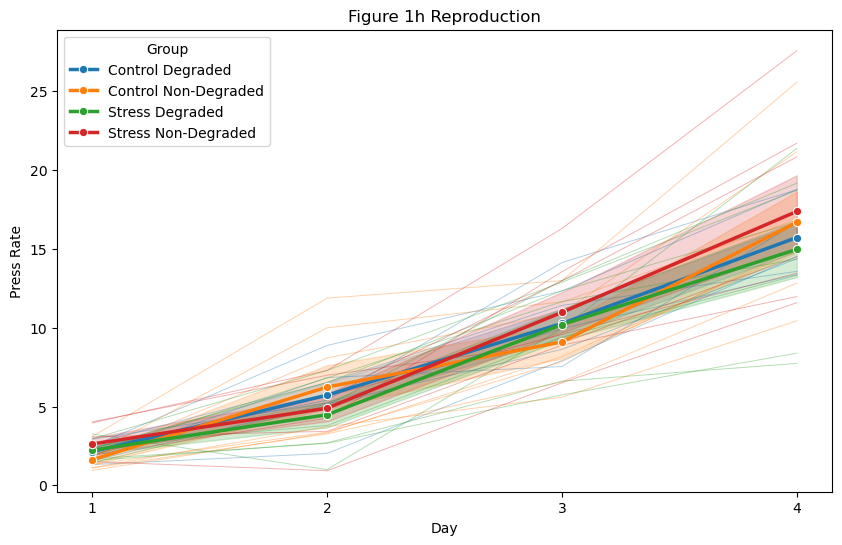

In [169]:
# Plot for Figure 1h

plt.figure(figsize=(10,6))

# Individual mouse lines

ind_mouse_line = sns.lineplot( 
    data=df_1h,
    x='Day',
    y='PressRate',
    hue='Group',
    estimator=None,
    units='Subject_ID',
    lw=0.7,
    alpha=0.35,
    legend=False     
)

# Main lines
main_group = sns.lineplot(
    data=df_1h,
    x='Day',
    y='PressRate',
    hue='Group',
    errorbar='se',
    lw=2.5,
    marker='o'
)

plt.title('Figure 1h Reproduction')
plt.xlabel('Day')
plt.xticks([1, 2, 3, 4])
plt.ylabel('Press Rate')
plt.show()


In [194]:
# Figure 1h STATISTICAL ANALYSIS

anova = pg.mixed_anova(
    dv='PressRate',
    within='Day',
    between='Group',
    subject='Subject_ID',
    data=df_1h
)

print(anova)

        Source           SS  DF1  DF2           MS           F         p-unc  \
0        Group    14.910402    3   25     4.970134    0.207350  8.903396e-01   
1          Day  3236.926166    3   75  1078.975389  210.845696  1.859144e-36   
2  Interaction    40.154902    9   75     4.461656    0.871865  5.539952e-01   

      p-GG-corr       np2       eps sphericity   W-spher   p-spher  
0           NaN  0.024278       NaN        NaN       NaN       NaN  
1  1.281160e-24  0.893998  0.603633      False  0.363513  0.000057  
2           NaN  0.094714       NaN        NaN       NaN       NaN  


In [199]:
rmanova = pg.rm_anova(data=data_1h, 
            dv='Press Rate', 
            within='Group', 
            subject='Subject_ID', 
            correction='auto', 
            detailed=False, 
            effsize='ng2')

KeyError: 'Press Rate'

In [171]:
# Ensure categorical types
df_1h['Stress'] = df_1h['Stress'].astype('category')
df_1h['Group'] = df_1h['Group'].astype('category')

# Fit 2×2 ANOVA
model = ols('PressRate ~ C(Stress) * C(Group)', data=df_1h).fit()
anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

                         sum_sq     df          F        PR(>F)
Intercept           2007.390229    1.0  52.774882  5.323055e-11
C(Stress)              0.000603    1.0   0.000016  9.968297e-01
C(Group)              14.910402    3.0   0.130666  9.416735e-01
C(Stress):C(Group)    22.333968    3.0   0.195722  8.225212e-01
Residual            4260.127143  112.0        NaN           NaN


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [172]:
# Need to do RM ANOVA here

In [180]:
# Figure 1i DATA LOADING

data_1i = pd.read_csv('1i.csv')

data_1i = data_1i.rename(columns={'Subject ID': 'Subject_ID', 'Press Rate': 'Press_Rate'}) # Rename columns

data_1i = data_1i.rename(columns={'Previous Experience': 'Previous_Experience'})


data_1i['Group'] = data_1i['Group'].astype('category')

data_1i['Previous_Experience'] = data_1i['Previous_Experience'].astype('category')

print(data_1i.head(30))

   Subject_ID Sex Age at Start   Strain Previous_Experience  \
0    JG28 #17   M      9 weeks  C57/Bl6            Handling   
1    JG28 #18   M      9 weeks  C57/Bl6            Handling   
2    JG28 #19   M      9 weeks  C57/Bl6            Handling   
3    JG28 #20   M      9 weeks  C57/Bl6            Handling   
4    JG28 #21   F      9 weeks  C57/Bl6            Handling   
5    JG28 #22   F      9 weeks  C57/Bl6            Handling   
6    JG28 #23   F      9 weeks  C57/Bl6            Handling   
7    JG28 #25   M      9 weeks  C57/Bl6            Handling   
8    JG28 #26   M      9 weeks  C57/Bl6            Handling   
9    JG28 #27   M      9 weeks  C57/Bl6            Handling   
10   JG28 #29   F      9 weeks  C57/Bl6            Handling   
11   JG28 #30   F      9 weeks  C57/Bl6            Handling   
12   JG28 #31   F      9 weeks  C57/Bl6            Handling   
13   JG28 #32   F      9 weeks  C57/Bl6            Handling   
14    JG28 #1   M      9 weeks  C57/Bl6              St

In [ ]:
#Fixing Figure 1i ANOVA DATA LOADING

data_1i_anova = pd.read_csv('1i_anova.csv')

data_1i_anova = data_1i_anova.rename(columns={'Subject ID': 'Subject_ID', 'Press Rate': 'Press_Rate'}) # Rename columns

data_1i_anova = data_1i_anova.rename(columns={'Previous Experience': 'Previous_Experience'})


data_1i_anova['Group'] = data_1i_anova['Group'].astype('category')

data_1i_anova['Previous_Experience'] = data_1i_anova['Previous_Experience'].astype('category')

print(data_1i_anova.head(30))

   Subject_ID Sex Age at Start   Strain Previous_Experience         Group  \
0    JG28 #17   M      9 weeks  C57/Bl6            Handling      Degraded   
1    JG28 #18   M      9 weeks  C57/Bl6            Handling      Degraded   
2    JG28 #19   M      9 weeks  C57/Bl6            Handling      Degraded   
3    JG28 #20   M      9 weeks  C57/Bl6            Handling      Degraded   
4    JG28 #21   F      9 weeks  C57/Bl6            Handling      Degraded   
5    JG28 #22   F      9 weeks  C57/Bl6            Handling      Degraded   
6    JG28 #23   F      9 weeks  C57/Bl6            Handling      Degraded   
7    JG28 #25   M      9 weeks  C57/Bl6            Handling  Non-Degraded   
8    JG28 #26   M      9 weeks  C57/Bl6            Handling  Non-Degraded   
9    JG28 #27   M      9 weeks  C57/Bl6            Handling  Non-Degraded   
10   JG28 #29   F      9 weeks  C57/Bl6            Handling  Non-Degraded   
11   JG28 #30   F      9 weeks  C57/Bl6            Handling  Non-Degraded   

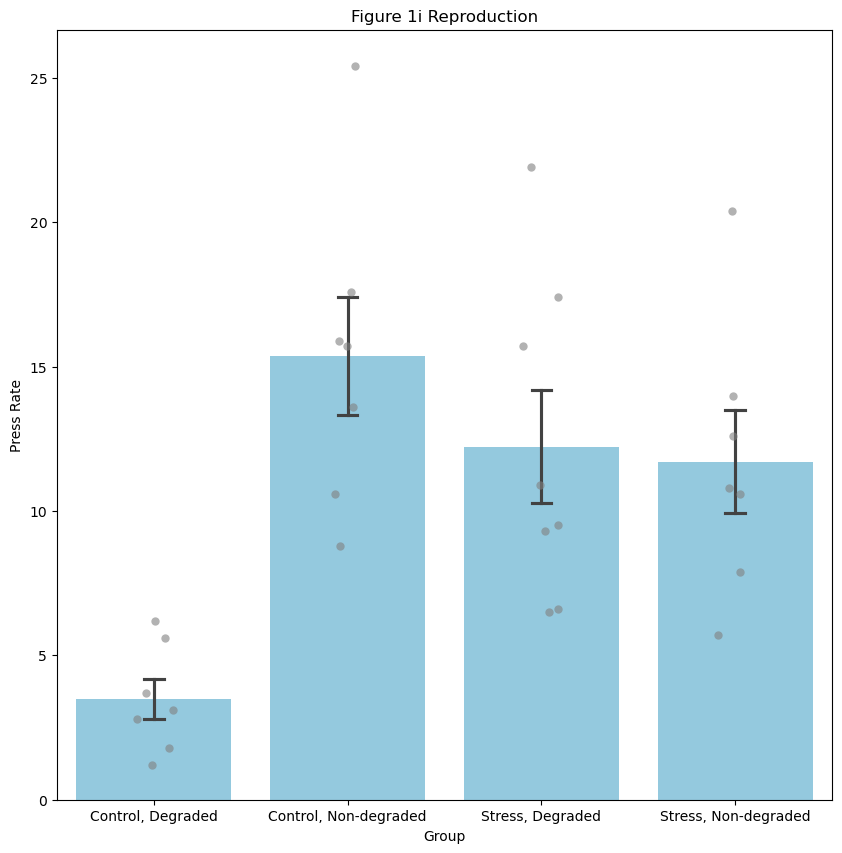

In [183]:
# Plot for Figure 1i

plt.figure(figsize=(10,10)) #make figure bigger

# Bar plot: mean ± SE
sns.barplot(
    data=data_1i,
    x='Group',
    y='Press_Rate',
    errorbar=('se'),          # standard error
    capsize=0.1,
    color='skyblue'
)

# Individual values
sns.stripplot(
    data=data_1i,
    x='Group',
    y='Press_Rate',
    jitter=True,
    color='gray',     # lighter color for individual points
    alpha=0.6,
    size=6
)

plt.title('Figure 1i Reproduction')
plt.xlabel('Group')
plt.ylabel('Press Rate')
plt.show()

In [ ]:
# Need to do ANOVA here

In [ ]:
# Figure 1i two way anova

pg.anova(
    data=data_1i_anova,
    dv='Press_Rate',
    between=['Previous_Experience', 'Group']
)

,Source,SS,DF,MS,F,p-unc,np2
0,Previous_Experience,54.345167,1.0,54.345167,2.495432,0.126748,0.090758
1,Group,217.819453,1.0,217.819453,10.001877,0.004072,0.285753
2,Previous_Experience * Group,277.600023,1.0,277.600023,12.746893,0.001480,0.337694
3,Residual,544.446429,25.0,21.777857,NaN,NaN,NaN
